In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score, adjusted_rand_score

# from Old.Clustering_and_QC import df_filtered
from src.plotting_functions import *
from src.column_spec import ColumnSpec
from src.clustering import *
from src.filters import *

from src.QC import *
from src.plotting_functions import *
# pio.renderers.default = "png"


In [2]:
df_batch = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv", sep="\t", low_memory=False)
# df_non = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260819_peptide_MS2quant_Norm_preprocessed.tsv", sep="\t", low_memory=False)



In [4]:
CELL_LINES = ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A", "MIX"] # MIX
CL_SELECTION = ["WT"]
CONDITION = ["_EGF_"]
DATA_TYPE = "raw:abs"

In [22]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the full analysis
# ════════════════════════════════════════════════════════════

df_raw = df_batch                      # dataset to cluster

CELL_LINES = ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"] # MIX
CL_SELECTION = ["WT"]
GROUPS = {"1": [ "WT"]} # if None coverage will be calculated for  all cell_lines independtely and the ALL. If a dictionary is defined, coverage can be checked for groups of cell lines (e.g. {"1": ["WT", "EGFRT693A"]}
CHOSEN_GROUP = "1" # Group chosen for the filtering
REMOVE_NON_GROUPS = False

CONDITIONS   = ["_EGF_"]
COVERAGE_DATA_TYPE = "raw:abs"
CLUSTER_DATA_TYPE    = "log2:FC"
EXCLUDE_FULL = True

# Filtering
MIN_REPS = 2
MIN_FC   = 0.5                      # |log2FC| threshold (extremes mode)
MAX_FFDR = None                      # limma omnibus F-test FDR cutoff (set to None to skip)

# Final clustering (set after inspecting the k-scan summary)
K_FINAL     = 15
CLUSTER_COL = f"clustering_on_WT_log2FC_15"

# ── Derived — do not edit ────────────────────────────────────────────────────
_scan_cols   = ColumnSpec.select(df_raw, # Extract columns that are going to be used for the custering
                                 cell_lines=GROUPS[CHOSEN_GROUP],
                                 data_type=CLUSTER_DATA_TYPE,
                                 conditions=CONDITIONS,
                                 exclude_full=EXCLUDE_FULL,
                                 exclude_replicate_cols=True)
N_DIMS       = len(GROUPS[CHOSEN_GROUP]) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS
print(f"Columns selected: {len(_scan_cols)}  |  Dimensions: {N_DIMS}  |  Timepoints per condition: {N_TIMEPOINTS}")
print(f"Columns to be used for the clustering: {_scan_cols}")

Columns selected: 8  |  Dimensions: 1  |  Timepoints per condition: 8
Columns to be used for the clustering: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_20', 'WT_log2:FC_EGF_30', 'WT_log2:FC_EGF_90']


## Using coverage for filtering

In [42]:
# Get coverage matrix
coverage_matrix = replicate_coverage_matrix(df_raw,
                                            cell_lines= CELL_LINES, # None == check all cell lines (None will also take the MIX contorls)
                                            conditions=CONDITION,
                                            data_type=COVERAGE_DATA_TYPE, # for coverage data type with replicate info it is necessary
                                            timepoints=None, #possibilty of specifying time points
                                            exclude_full=False,
                                            exclude_starve=False,
                                            missing_value=0.0,
                                            site_col= "site") # column used to identify the phosphosite the coverage info is being retreived

# One column per cell line, plus an "ALL" group: sites with a complete (or a set defined by timepoints in replicate_coverage_matrix()) time course in every cell line at the same time.
depth = replicate_coverage_depth(counts = coverage_matrix,
                                 groups = GROUPS, # takes group name or a list with the cell lines. If groups == None, it will retrieve info for all cell lines
                                 include_all=True,) # Returns the coverage per site per cell line.


# For grouping here, you have to define and calculate the groups for the replicate_coverage_depth()
coverage_table = coverage_summary(depth = depth,
                                  max_depth= None, # if None, then the result provides for each cell line the amount of sites with full time_courses with 1, 2, or 3 replicates per timepoint
                                  print_summary = True,)
# Apply the coverage filter
df_cov_f = filter_by_coverage(df = df_raw,
                              depth = depth,
                              group= "ALL",# "ALL", # cell lines in which the coverage thrshold is checked
                              min_reps=1,
                              )
if REMOVE_NON_GROUPS == True:
    NON_CL_SELECTION = [element for element in CELL_LINES if element not in GROUPS[CHOSEN_GROUP]]
    print(f"Un-selected cell lines: {NON_CL_SELECTION}")

    prefixes = tuple(f"{cl}_" for cl in NON_CL_SELECTION) # prefixes mus be defines because i have the biological replicate of BRAFS151A (if not i could not choose between one biological replicate or the other
    dropping_cols = [element for element in df_cov_f.columns.tolist() if element.startswith(tuple(prefixes))]

    df_cov_f = df_cov_f.drop(columns=dropping_cols)

df_cov_f


Replicate coverage per timepoint (71087 sites total):
  1                    ≥1 rep : 23175 (32.6%) | ≥2 reps: 10700 (15.1%) | ≥3 reps: 4972 (7.0%)
  ALL                  ≥1 rep : 11397 (16.0%) | ≥2 reps: 5798 (8.2%) | ≥3 reps: 243 (0.3%)


,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,RPS6KA3S375A_log2:FFDR_ALL_omnibus,RPS6KA3S375A_log2:adjustedFFDR_EGF_omnibus,RPS6KA3S375A_log2:adjustedFFDR_ALL_omnibus,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT
9,P0DMV8_362_371_1_1_S362,HSPA1A,P0DMV8,DLNKSINPDEAVAYGAAVQAAILMGDK,LQDFFNGR.DLNKSINPDEAVAYGAAVQAAILMGDK.SENVQDLL,358,384,27,1.0000,P0DMV8,...,NaN,NaN,NaN,0.452000,False,NaN,NaN,NaN,NaN,NaN
12,Q96RK0_2306_2318_1_1_S2318,CIC,Q96RK0,NSTDLDSAPEDPTSPKR;RKNSTDLDSAPEDPTSPK;KNSTDLDSA...,GSYRKKRK.NSTDLDSAPEDPTSPK.RKMRRRSS,2305,2320,16,1.0000,Q96RK0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,P35269_385_400_1_1_T389,GTF2F1,P35269,GNSRPGTPSAEGGSTSSTLR,KPSGGSSR.GNSRPGTPSAEGGSTSSTLR.AAASKLEQ,383,402,20,1.0000,P35269,...,NaN,NaN,NaN,0.772932,True,human,"activity, inhibited","transcription, inhibited",NaN,NaN
26,Q71RC2_717_722_1_1_S722,LARP4,Q71RC2,EQYVPPRSPK;NGKEQYVPPRSPK,GVTRRNGK.EQYVPPRSPK.-,715,724,10,1.0000,Q71RC2,...,NaN,NaN,NaN,0.690329,True,NaN,NaN,NaN,NaN,NaN
32,Q9HD20_899_905_1_1_S899,ATP13A1,Q9HD20,DSPTLSNSGIR;RPRDSPTLSNSGIR,VERRRRPR.DSPTLSNSGIR.ATSRTAKQ,898,908,11,1.0000,Q9HD20,...,NaN,NaN,NaN,0.405902,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71055,P15336_253_272_1_0,ATF2,P15336,PVTMVPSVPGIPGPSSPQPVQSEAK,PAAVPLVR.PVTMVPSVPGIPGPSSPQPVQSEAK.MRLKAALT,251,275,25,1.0000,P15336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71057,Q68EM7_808_834_1_1_S808,ARHGAP17,Q68EM7,NRPSVPPPPQPPGVHSAGDSSLTNTAPTASK,PRPVPKPR.NRPSVPPPPQPPGVHSAGDSSLTNTAPTASK.IVTDSNSR,805,835,31,1.0000,Q68EM7,...,NaN,NaN,NaN,0.253025,False,NaN,NaN,NaN,NaN,NaN
71068,Q9HCK8_1993_2023_2_2_S1995S2008,CHD8,Q9HCK8,TASPLPLRPDAPVEKSPEETATQVPSLESLTLK,LHQQYTSR.TASPLPLRPDAPVEKSPEETATQVPSLESLTLK.LEH...,1993,2025,33,1.0000,Q9HCK8,...,NaN,NaN,NaN,0.431316,True|True,NaN,NaN,NaN,NaN,NaN
71082,Q13112_507_538_1_1_S538,CHAF1B,Q13112,TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELKR;TDTPPSS...,RINLTPLK.TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELK...,507,543,37,1.0000,Q13112,...,NaN,NaN,NaN,0.538663,True,NaN,NaN,NaN,NaN,NaN


### Add the FC filter

In [30]:
df_cov_f = filter_dynamics(df = df_cov_f,
                           data_type="log2:FC",
                           threshold=0.5,
                           exclude_full = False,
                           conditions = ["_EGF_"],
                           cell_lines = GROUPS[CHOSEN_GROUP],
                           )
print(f"Dataframe after selecting log2:FC > 0.5: {df_cov_f.shape}")


Dataframe after selecting log2:FC > 0.5: (5534, 1559)


## Clustering

In [31]:
# df_clustered is the results df with the labels of to which cluster each site belongs
# clustering_model is the parameters of the model used. tslearn model (functions can be applyed to the model)
# multivariate is the np matrix reshaped and only carring the time points information
# barycenters are the clusters centroids
df_clustered, clustering_model, multivariate, barycenters = tslearn_clustering_KMeans(
    df_to_cluster=df_cov_f.copy(),
    data_type=CLUSTER_DATA_TYPE,
    condition_for_clustering=CONDITIONS,
    cell_lines=GROUPS[CHOSEN_GROUP], #GROUPS[CHOSEN_GROUP], # this can be marked as individuals
    exclude_full=EXCLUDE_FULL,
    stoichiometry=None,
    cluster_column_name=CLUSTER_COL,
    number_of_clusters=K_FINAL,
    max_iterations=1000,
    n_init=25,
    metric="euclidean",
    df_dimensions=N_DIMS,
    time_series_length=N_TIMEPOINTS,
    random_state=0,
    transpose=True,
    verbose=True,
    testing=True,
    barycenter_calculations=True,
)
print(f"\nCluster sizes:\n{df_clustered[CLUSTER_COL].value_counts().sort_index()}")

Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_20', 'WT_log2:FC_EGF_30', 'WT_log2:FC_EGF_90']

Reshaping dataframe to shape (5534, 8, 1)

The size of the dataset is (5534, 8, 1)
Example:
[[ 0.        ]
 [-0.26697399]
 [-0.9236244 ]
 [-2.43283772]
 [-3.30387549]
 [-3.20418371]
 [-2.88301759]
 [-2.03042634]]
Init 1
0.661 --> 0.486 --> 0.463 --> 0.456 --> 0.452 --> 0.450 --> 0.449 --> 0.448 --> 0.448 --> 0.447 --> 0.447 --> 0.446 --> 0.446 --> 0.446 --> 0.446 --> 0.445 --> 0.445 --> 0.445 --> 0.444 --> 0.444 --> 0.444 --> 0.444 --> 0.444 --> 0.444 --> 0.444 --> 0.443 --> 0.443 --> 0.443 --> 0.442 --> 0.441 --> 0.440 --> 0.439 --> 0.438 --> 0.438 --> 0.437 --> 0.437 --> 0.437 --> 0.437 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 0.436 --> 

In [32]:
fig, ax = plot_sites_umap_interactive(df_clustered,
                                      cell_lines=GROUPS[CHOSEN_GROUP], #"WT", "BRAFS151A", "GAB1Y259A"],
                                      conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                      data_type="log2:FC",
                                      exclude_full=True,
                                      color_col=CLUSTER_COL, # None  "protein_name"
                                      hover_cols=None,
                                      n_neighbors=15,
                                      min_dist=0.1,
                                      random_state=42,
                                      figsize=(600, 400),
                                      title=None, )
fig.show()

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


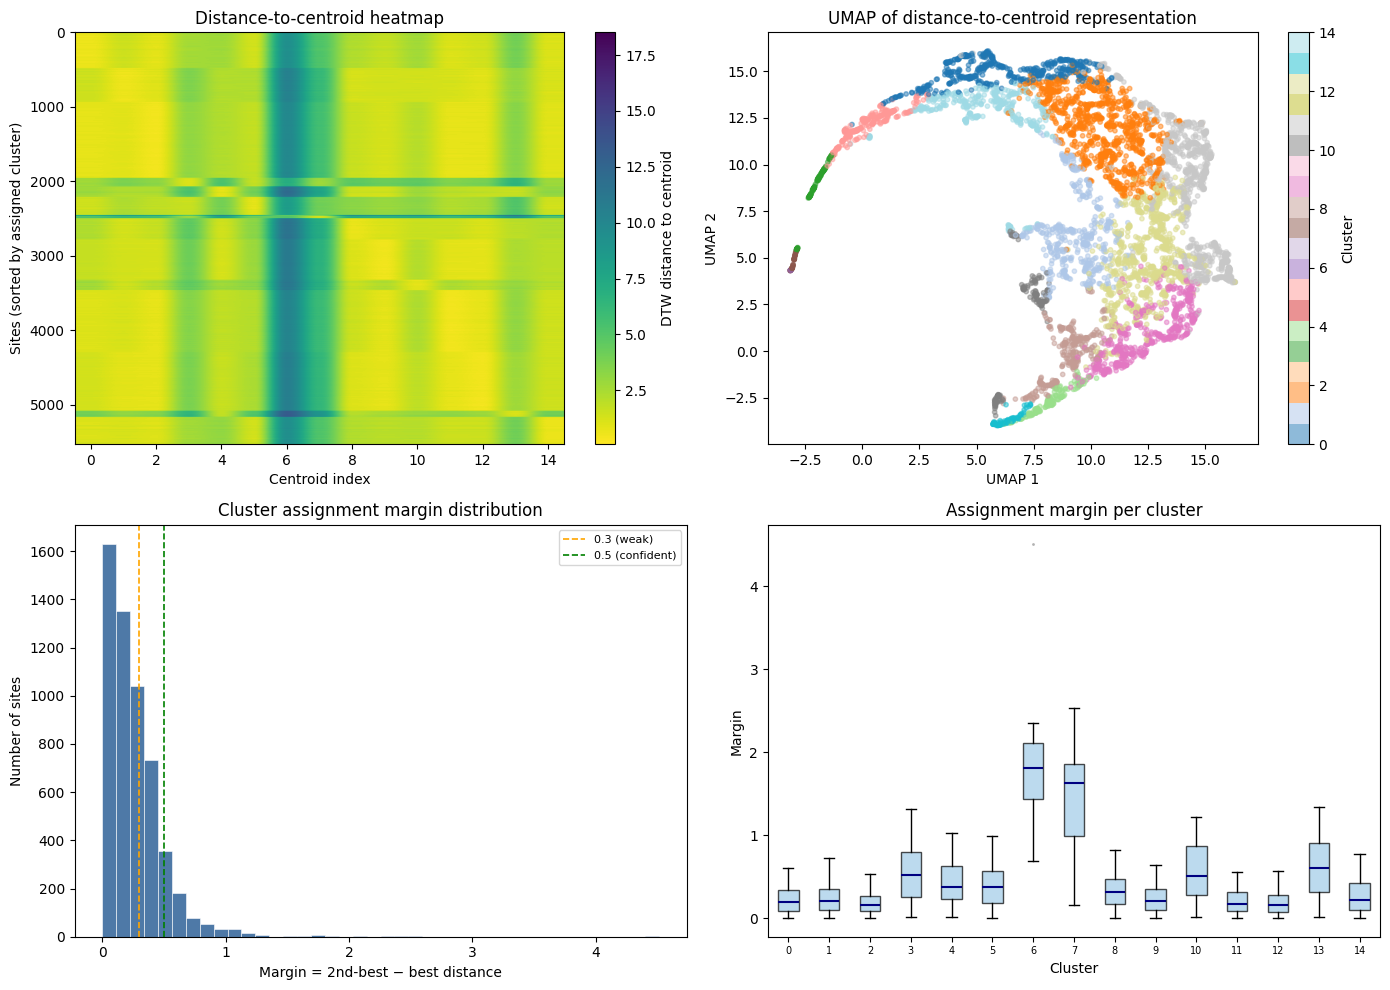

In [33]:
fig, axes = plot_cluster_assignment_qc(barycenters, clustering_model.labels_)
plt.show()

In [38]:
fc_cols   = ColumnSpec.select(df_cov_f, # Extract columns that are going to be used for the custering
                                 cell_lines=CELL_LINES,
                                 data_type=CLUSTER_DATA_TYPE,
                                 conditions=CONDITIONS,
                                 exclude_full=False,
                                 exclude_replicate_cols=True)
meta_col = ["site", "protein_Id", "protein_name", CLUSTER_COL]
all_col = meta_col + fc_cols
df_to_save = df_clustered[all_col]
# df_to_save.to_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260828_2rep_alltimepoits_allcellline_15clusters_onWT.tsv", sep="\t", index=False)


In [64]:
proteins_df = pd.read_csv("../../External_Data/Metadata/String/EGFR_signaling_string_interactions.tsv", sep="\t")
p_list = proteins_df["node2"].unique().tolist() + proteins_df["#node1"].unique().tolist()



In [68]:
#data for fabian
meta_col = ["site", "protein_Id", "protein_name"]
all_col = meta_col + fc_cols
proteins = ["EGFR", "SOS1", "AKT1", "AKT2", "AKT3", "MAPK3", "GAB1", "BRAF", "MAPK1", "MAPK2", "RAF1", "RAS", "MAP1K1", "MAP1K2", "PTPN11", "SHC1", "GRB2", "MAP3K1", "MAP2K4", "PAK1", "PIP3", "HRAS", "JUN", "PIK3CA", "SRC", "PDPK1", "MAP3K2", "MAPK8", "JAK", "JAK2", "STAT3"]

fabian_df = df_cov_f.loc[df_cov_f["protein_name"].isin(proteins)]
fabian_df = fabian_df[all_col]
# fabian_df.to_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260828_1rep_alltimepoits_allcellline_log2FC.tsv", sep="\t", index=False)
fabian_df

,site,protein_Id,protein_name,WT_log2:FC_EGF_full,WT_log2:FC_EGF_starve,WT_log2:FC_EGF_2,WT_log2:FC_EGF_5,WT_log2:FC_EGF_10,WT_log2:FC_EGF_15,WT_log2:FC_EGF_20,...,GAB1Y259A_log2:FC_EGF_90,RPS6KA3S375A_log2:FC_EGF_full,RPS6KA3S375A_log2:FC_EGF_starve,RPS6KA3S375A_log2:FC_EGF_2,RPS6KA3S375A_log2:FC_EGF_5,RPS6KA3S375A_log2:FC_EGF_10,RPS6KA3S375A_log2:FC_EGF_15,RPS6KA3S375A_log2:FC_EGF_20,RPS6KA3S375A_log2:FC_EGF_30,RPS6KA3S375A_log2:FC_EGF_90
896,Q13153_142_146_1_1_S144~YMSFTDK,Q13153,PAK1,-0.180007,0.0,-0.359469,-0.957489,-0.048416,-0.349732,-0.509356,...,-0.215815,-0.038840,0.0,0.021435,-0.023723,-0.530580,-0.081807,-0.194443,-0.811823,-0.667280
1781,P00533_1162_1172_1_1_S1166~GSHQISLDNPDYQQDFFPK,P00533,EGFR,-0.462970,0.0,0.104420,0.066383,-0.649987,-0.064656,-0.015853,...,-1.190217,-0.095575,0.0,0.233496,-0.549991,-0.171876,0.181551,-0.100571,0.271051,-0.045093
2625,P12931_69_75_1_1_S75~LFGGFNSSDTVTSPQR,P12931,SRC,-0.014783,0.0,-0.163626,-0.387402,-0.432286,-0.508892,-0.150489,...,-0.500960,0.750551,0.0,-0.199411,-0.136844,-0.035945,-0.208514,-0.107237,-0.078578,-0.249875
3226,Q13153_219_236_1_1_T230~DVATSPISPTENNTTPPDALTR,Q13153,PAK1,-0.113192,0.0,-0.259191,-0.156799,-0.454727,-0.293697,-0.045443,...,-0.622825,0.149038,0.0,-0.008408,-0.188134,-0.028234,0.155865,-0.179713,0.215605,-0.169806
5461,P04049_257_274_1_1_S259~STSTPNVHMVSTTLPVDSR,P04049,RAF1,-0.197577,0.0,-1.201757,-0.575501,-1.675610,-3.341245,-1.029749,...,-2.727891,0.978517,0.0,-0.263986,-1.281550,-0.531524,-0.367054,-0.692102,0.417599,-0.539607
5519,Q13153_165_197_1_1_S174~AVSETPAVPPVSEDEDDDDDDA...,Q13153,PAK1,-0.377340,0.0,0.027750,-0.392356,-0.311411,-0.309945,-0.305525,...,-0.527048,0.239011,0.0,0.400875,0.135234,0.575116,0.817666,0.495042,0.927501,0.585082
7649,P05412_231_249_1_1_S243~LQALKEEPQTVPEMPGETPPLS...,P05412,JUN,0.297140,0.0,-1.074907,-0.099532,-0.581857,-0.616639,0.274466,...,-0.097272,0.488640,0.0,-0.517571,-1.779494,-0.359124,-0.059036,-0.743625,0.364482,-0.369407
7754,P45985_5_36_1_1_S26~AAPSPSGGGGSGGGSGSGTPGPVGSP...,P45985,MAP2K4,-0.888696,0.0,0.165877,-0.931195,-0.994742,-0.988358,-0.622453,...,-0.184537,-0.324675,0.0,-0.084062,-0.071396,-0.445652,-0.515943,-0.427268,-0.522040,-0.484557
8476,Q13233_292_304_1_1_S292~RAPSPDGFSPYSPEETNR,Q13233,MAP3K1,-0.686375,0.0,-0.519603,-0.873932,-1.540890,-1.057229,-0.443166,...,0.112402,-0.766503,0.0,-0.862863,-0.213895,-0.657312,-0.497146,-0.577012,-0.241720,-0.525049
10299,Q07889_1202_1210_1_1_S1210~TSISDPPESPPLLPPREPVR,Q07889,SOS1,-0.038267,0.0,-0.190772,-0.765344,-1.058774,-1.003599,-0.152649,...,0.107236,-0.609714,0.0,-0.357767,0.101624,-1.024586,-1.214618,-0.814630,-0.287001,-0.286597


# What would happen if i filter out sites with an assignment distribution lower than 0.3 and then plot the clusters of those site?

# cluster visualization

 Plot not saved


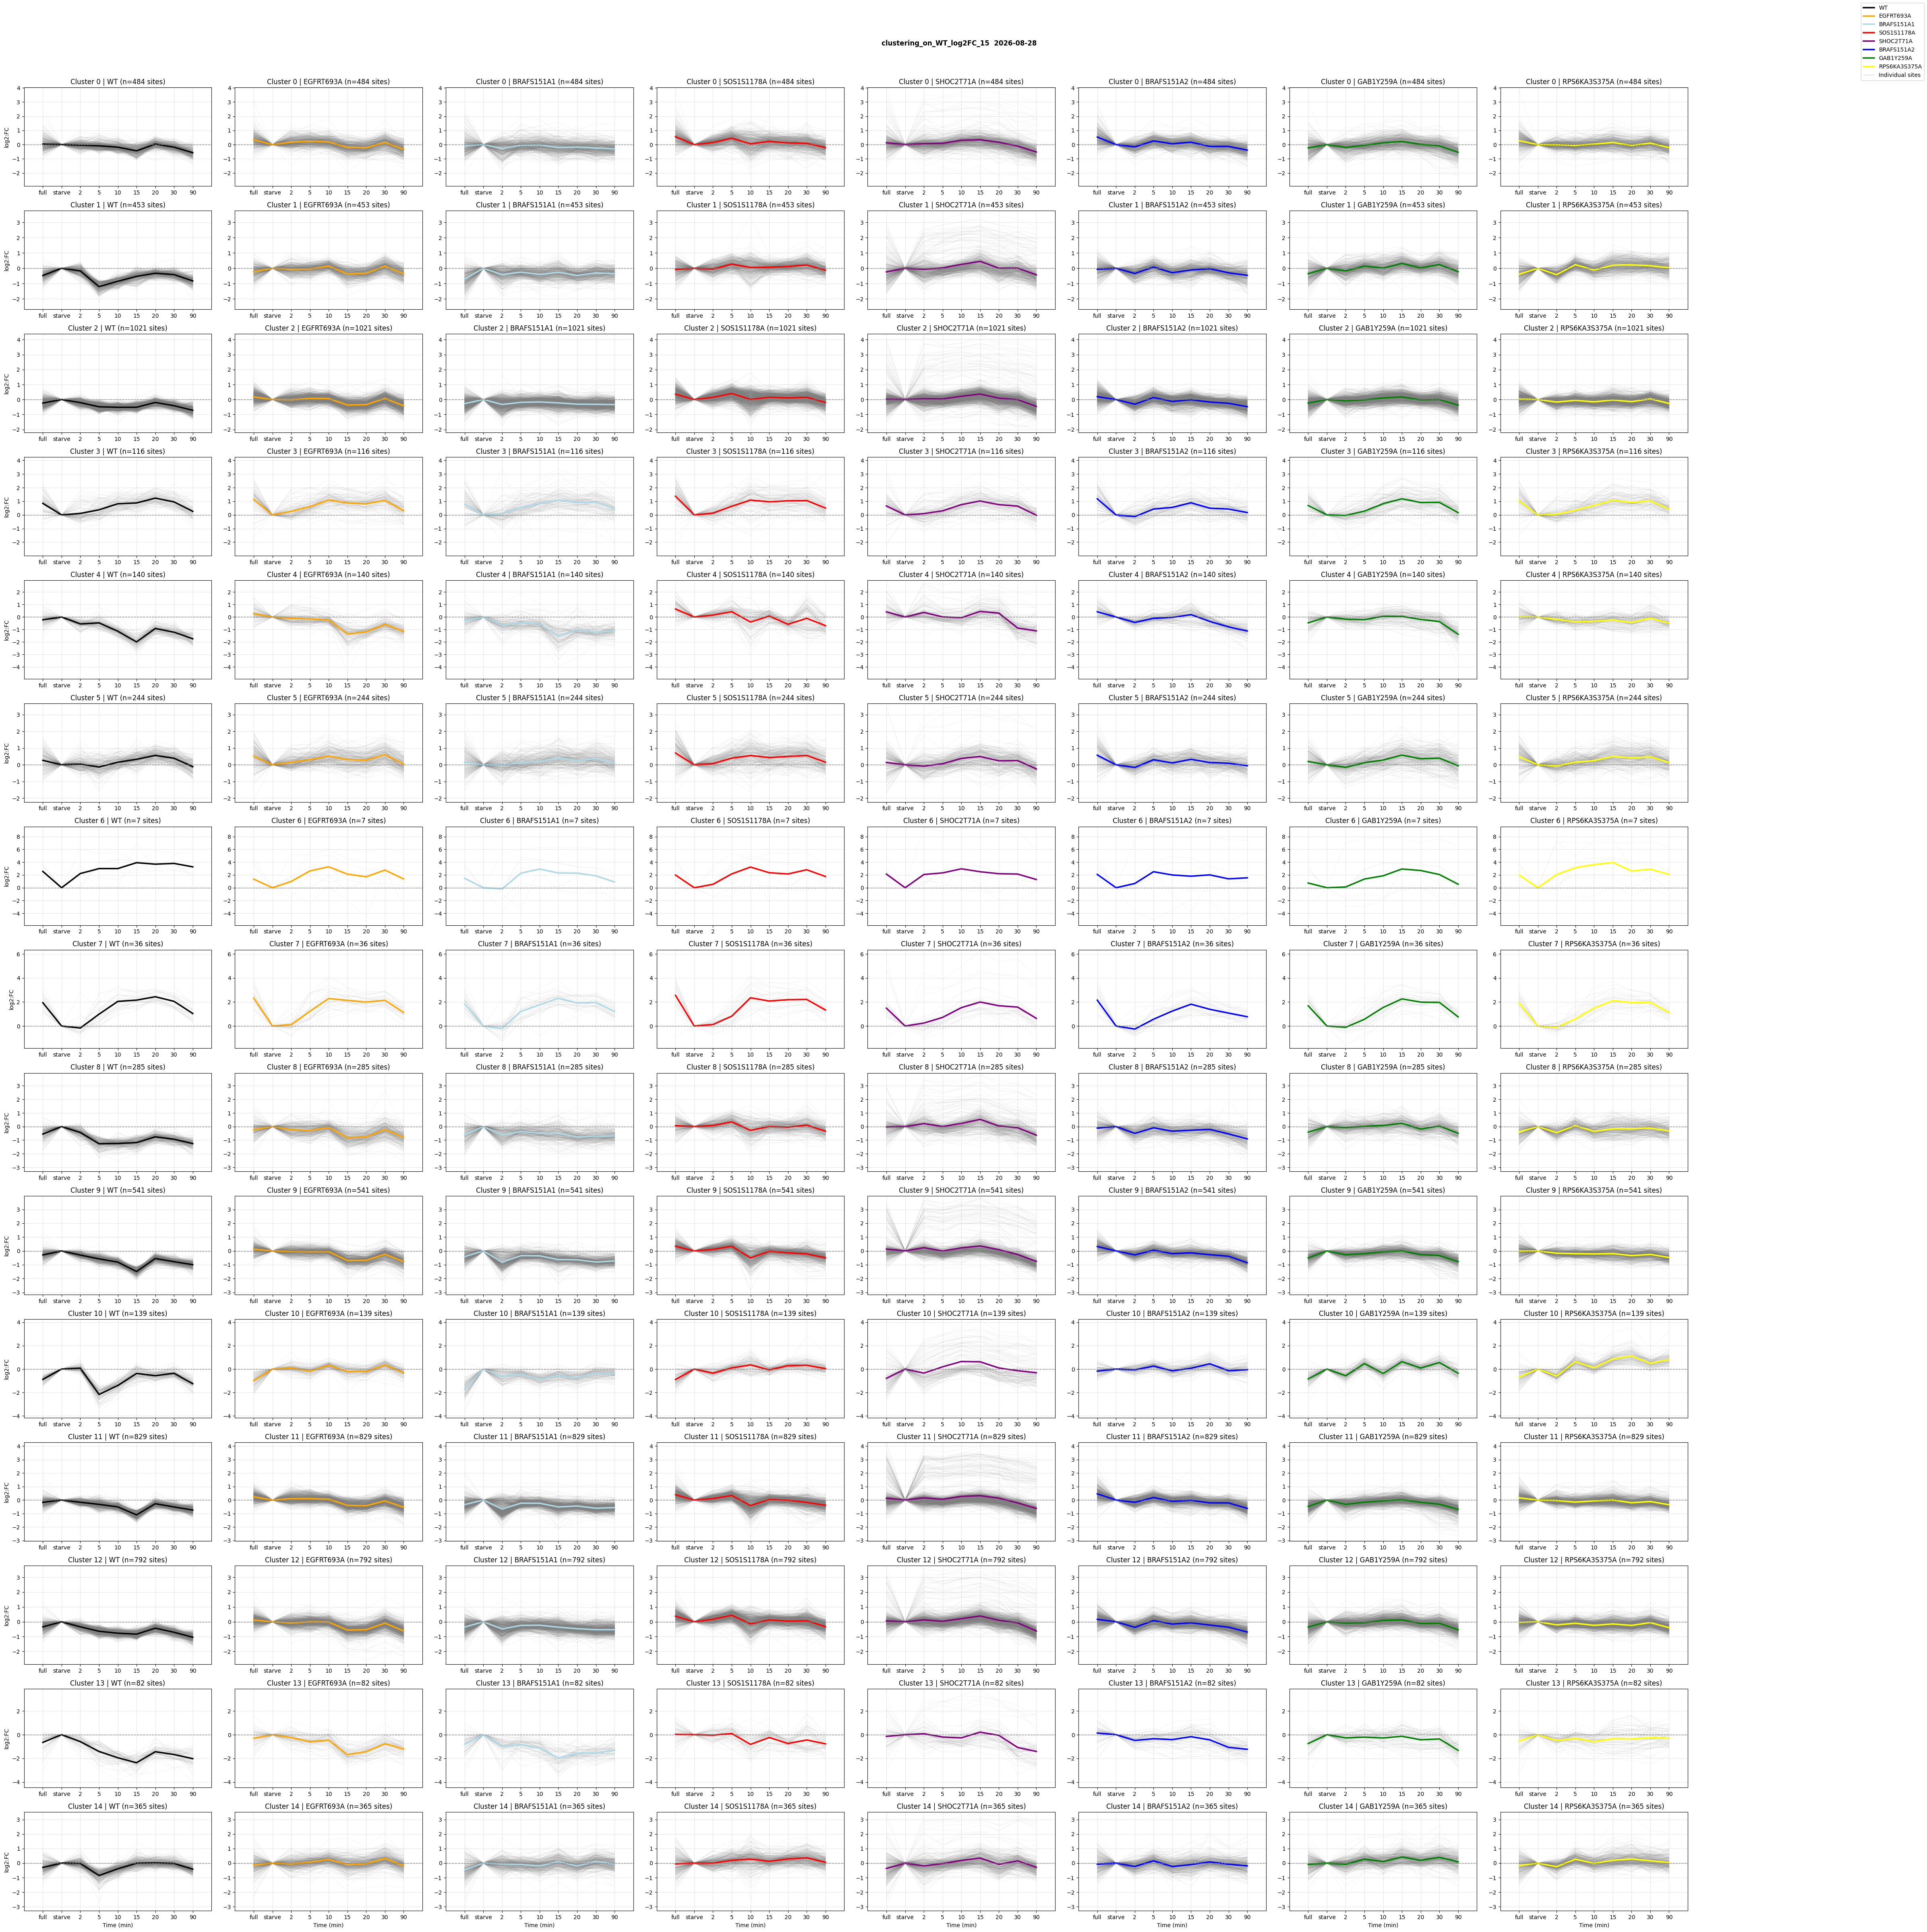

In [39]:
clusters_plot_linear_mutants(
    df                  = df_clustered,
    cluster_column      = CLUSTER_COL,
    data_type           = CLUSTER_DATA_TYPE, # DATA_TYPE, "log2:FC"  "log2:scaled" "lod2:zscore"
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    colors              = {"WT" : "black",
                           "EGFRT693A" : "orange",
                           "BRAFS151A1" : "lightblue",
                           "SOS1S1178A" : "red",
                           "SHOC2T71A" : "purple",
                           "BRAFS151A2" : "blue",
                           "GAB1Y259A" : "green",
                           "RPS6KA3S375A" : "yellow", },
    panel_by            = "cell_line", # condition cell_line
    plot_different_data = True,
    legend              = None,
    saving_path         = "",
    saving_info         = "",
    save_pdf            = False,
    save_png            = False,
    plot_close          = False,
    fit_y_lims          = False,
    grey_alpha          = 0.08,
    grey_lw             = 0.8,
    mean_lw             = 2.6,
)

In [179]:
cluster_subset =df_clustered.loc[df_clustered[CLUSTER_COL] == 2]

cluster_subset_FC = filter_dynamics(df = cluster_subset,
                           data_type="log2:FC",
                           threshold=2,
                           exclude_full = False,
                           conditions = ["_EGF_"],
                           cell_lines = "SHOC2T71A",
                           )
print(cluster_subset_FC.shape)

cluster_proteins = cluster_subset_FC["protein_name"].unique()
print(len(cluster_proteins))
cluster_proteins

(85, 1560)
70


array(['FAM83H', 'TXNRD1', 'THRAP3', 'KRT14', 'MORC2', 'MKI67', 'PPAN',
       'CSNK2B', 'PHLDB1', 'TNKS1BP1', 'KRT6A', 'KRT18', 'RBM25',
       'CTNND1', 'LIMA1', 'HSP90AA1', 'BAZ1B', 'EIF4G1', 'VIM', 'MICALL1',
       'EDC4', 'PGRMC1', 'AHNAK2', 'KRT5', 'AHNAK', 'PLEC', 'MAP2K2',
       'PALLD', 'LARP1', 'NMT1', 'SUMO1', 'DPYSL3', 'CSTF3', 'NDRG1',
       'PI4K2A', 'TRIM28', 'LMNA', 'CANX', 'RABL6', 'BCLAF1', 'ZDHHC5',
       'PDCD4', 'MCM2', 'HAUS8', 'GPS1', 'DDX21', 'KRI1', 'CRYBG1',
       'MARCKS', 'H1-4', 'SPTLC2', 'HNRNPA3', 'LSM14A', 'SSB', 'SRRM2',
       'EIF5B', 'PRKAR2A', 'ACLY', 'SPEN', 'CLNS1A', 'SMARCA4', 'AGFG1',
       'COL17A1', 'NUCKS1', 'SEC31A', 'LMNB1', 'TMEM40', 'ITGB4',
       'SEPTIN2', 'DDX42'], dtype=object)

Ploting sites of protein LMNA
LMNA_P02545_log2:FC_ — plot not saved
Ploting sites of protein BCLAF1
BCLAF1_Q9NYF8_log2:FC_ — plot not saved
Ploting sites of protein ACLY
ACLY_P53396_log2:FC_ — plot not saved


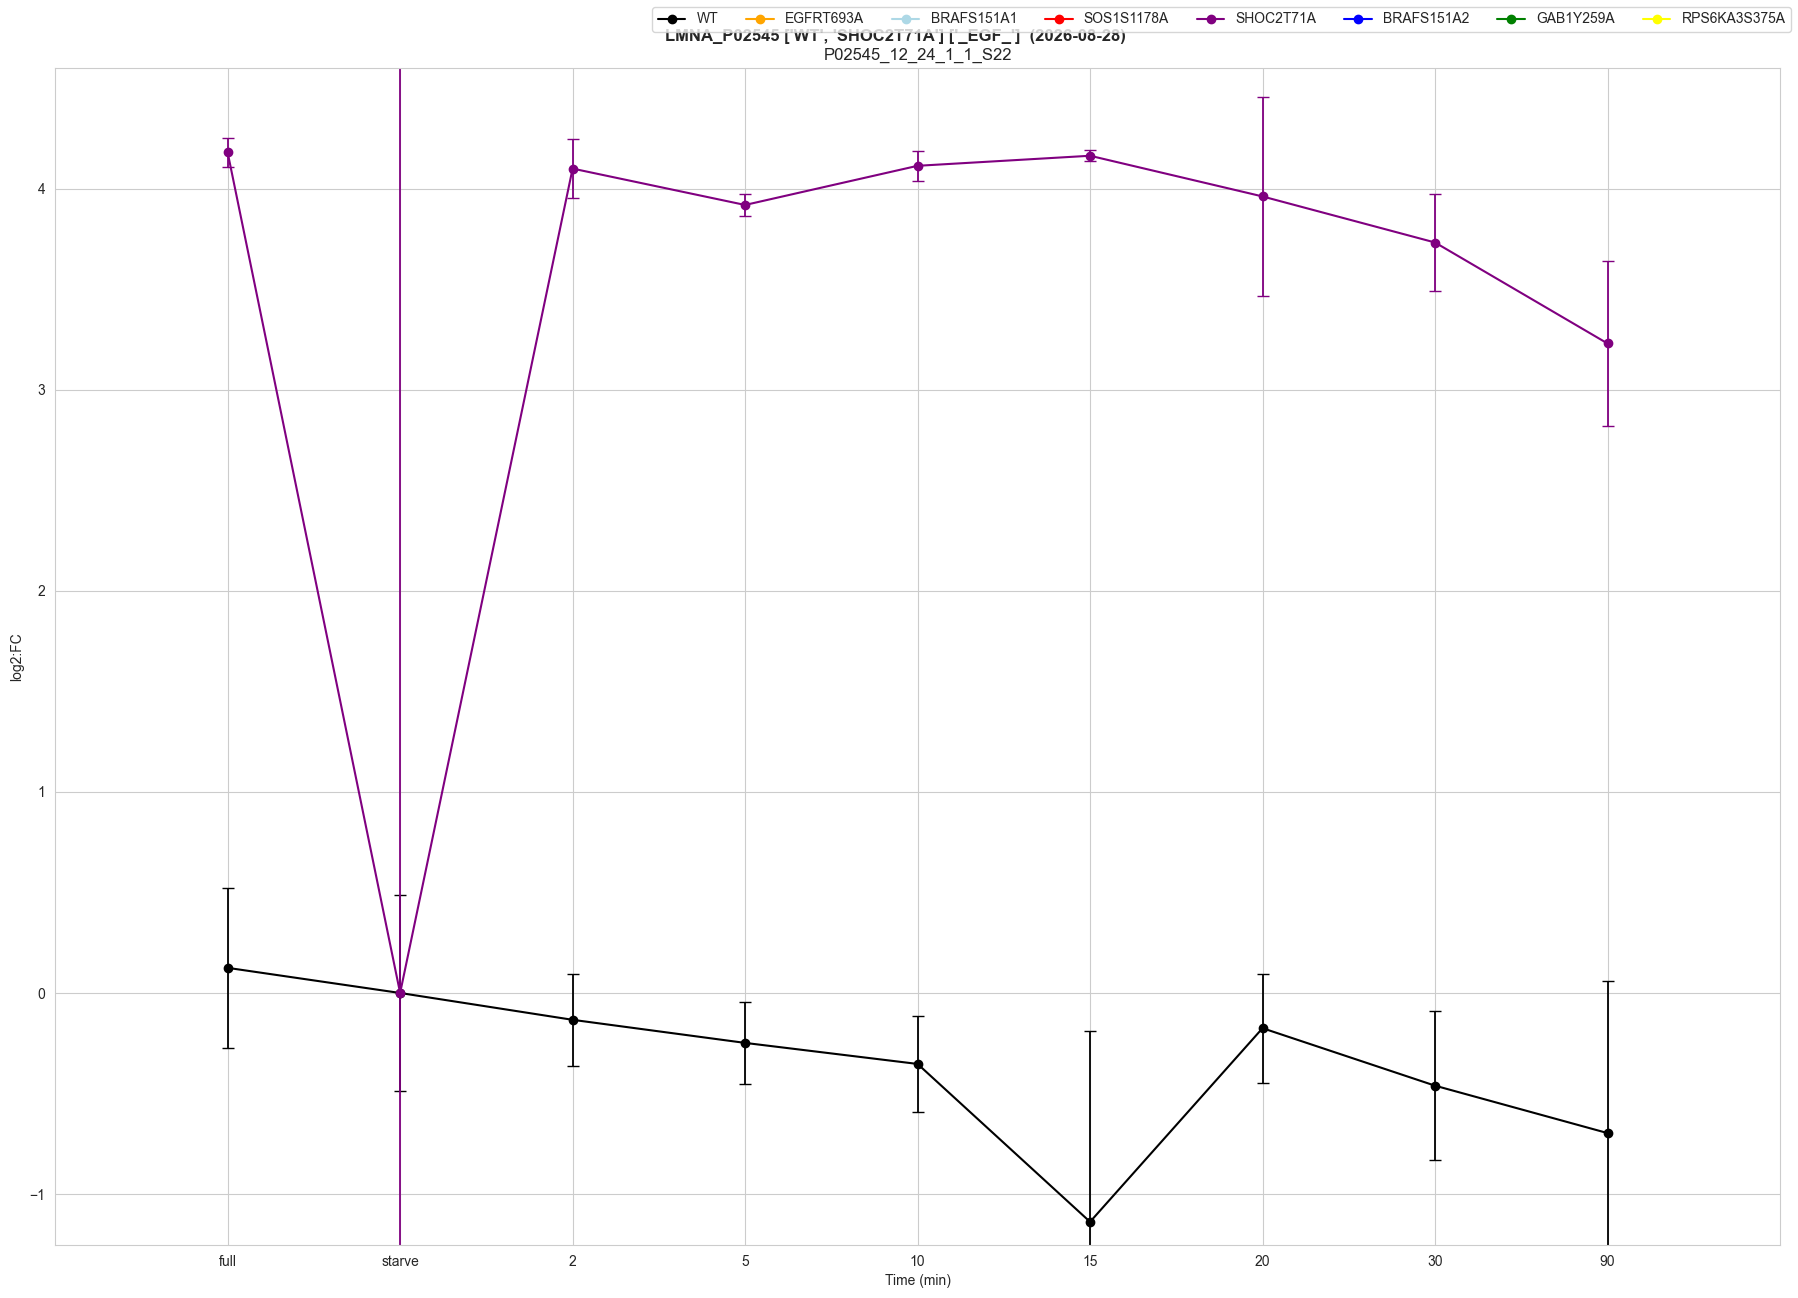

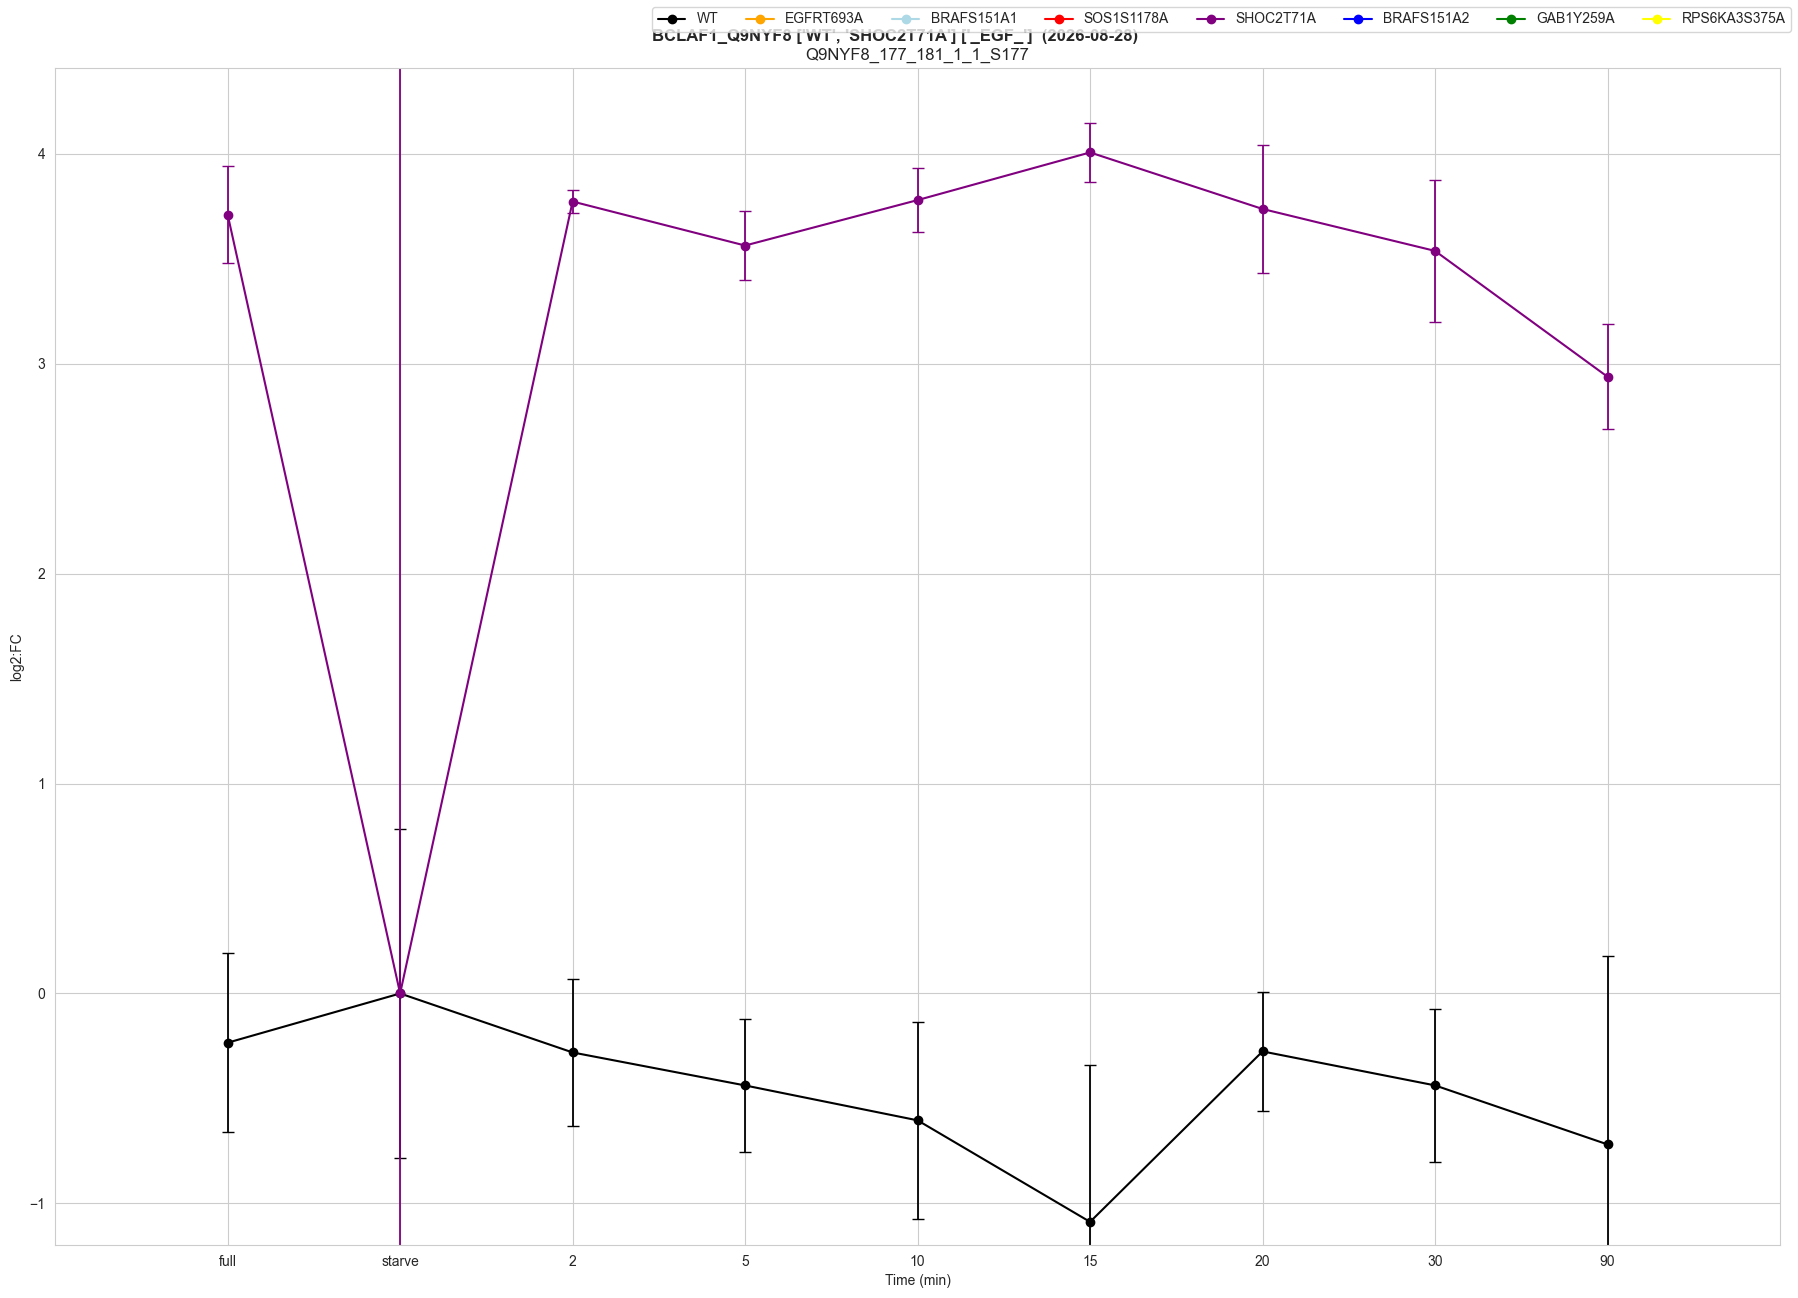

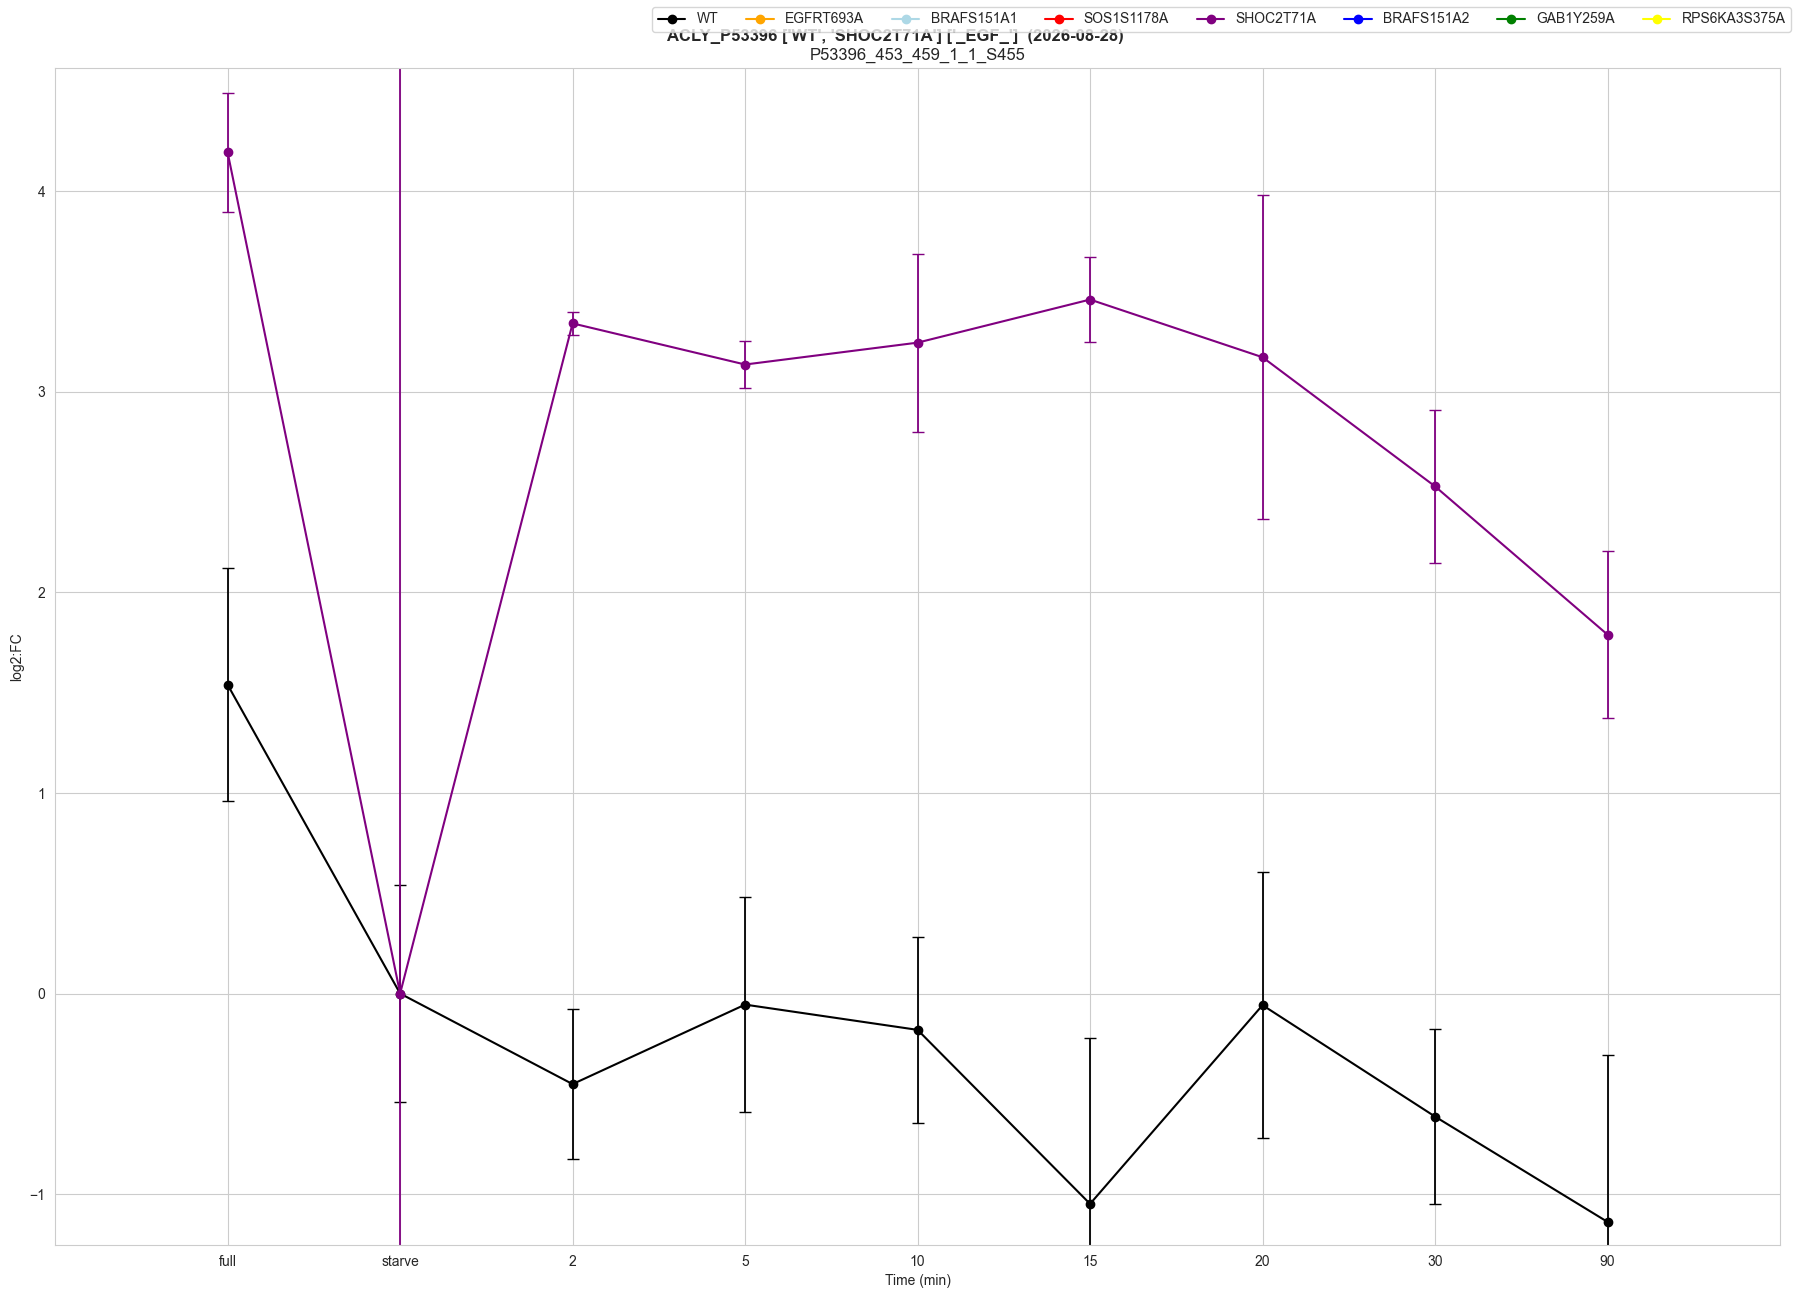

In [162]:
plot_protein_phosphosites(df = cluster_subset_FC,
                          data_type="log2:FC",
                          proteins=cluster_proteins,
                          cell_lines= ["WT", "SHOC2T71A" ], # ["WT", "EGFRT693A", "SOS1S1178A", "GAB1Y259A", "BRAFS151A2", "SHOC2T71A"],
                          conditions=['_EGF_'],
                          legend_plot=CELL_LINES,
                          color_palette={"WT" : "black",
                                         "EGFRT693A" : "orange",
                                         "BRAFS151A1" : "lightblue",
                                         "SOS1S1178A" : "red",
                                         "SHOC2T71A" : "purple",
                                         "BRAFS151A2" : "blue",
                                         "GAB1Y259A" : "green",
                                         "RPS6KA3S375A" : "yellow", },
                          saving_path="",
                          saving_info="",
                          title_info="",
                          fit_y_lims= True,
                          one_figure_per_site=False,
                          plot_close=False,
                          save_pdf=False,
                          save_png=False,
                          )
